In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [31]:
def load_img():
    blank_img = np.zeros((600,800))
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img, text = 'DHARSH', 
                org = (50,300), fontFace = font, fontScale = 5,
                color = (255,255,255), thickness = 25, lineType = cv2.LINE_AA)
    return blank_img

In [32]:
def display_img(img):
    fig = plt.figure(figsize = (12,10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap = 'gray')
    plt.show()

In [33]:
img = load_img()

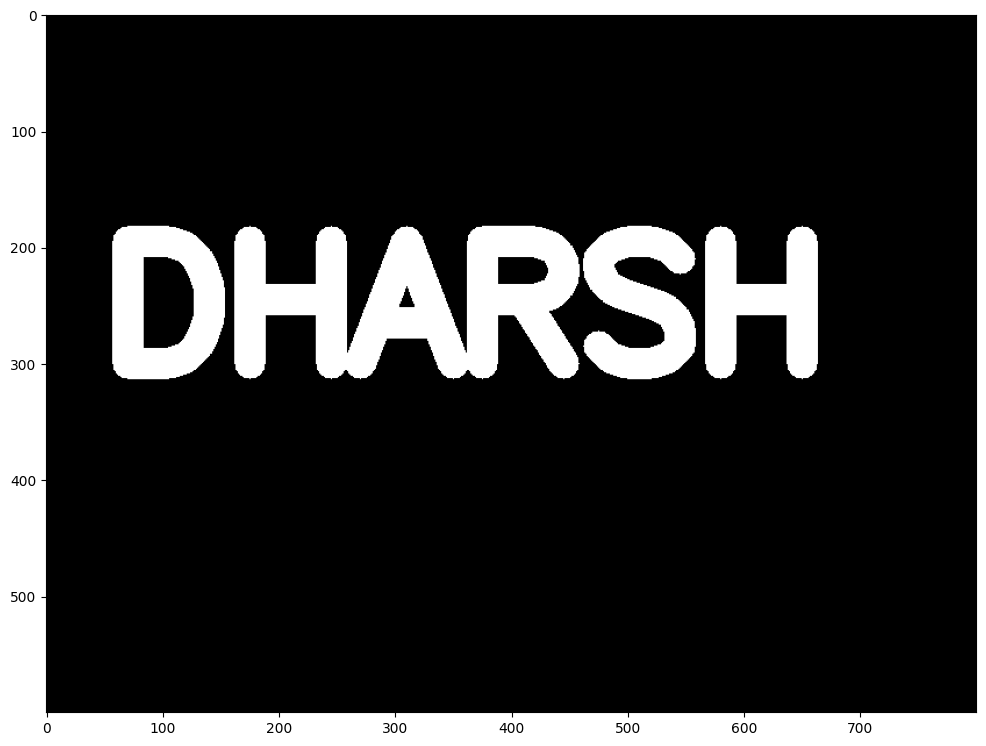

In [34]:
display_img(img)

In [37]:
kernel=np.ones((5,5), dtype=np.uint8)
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

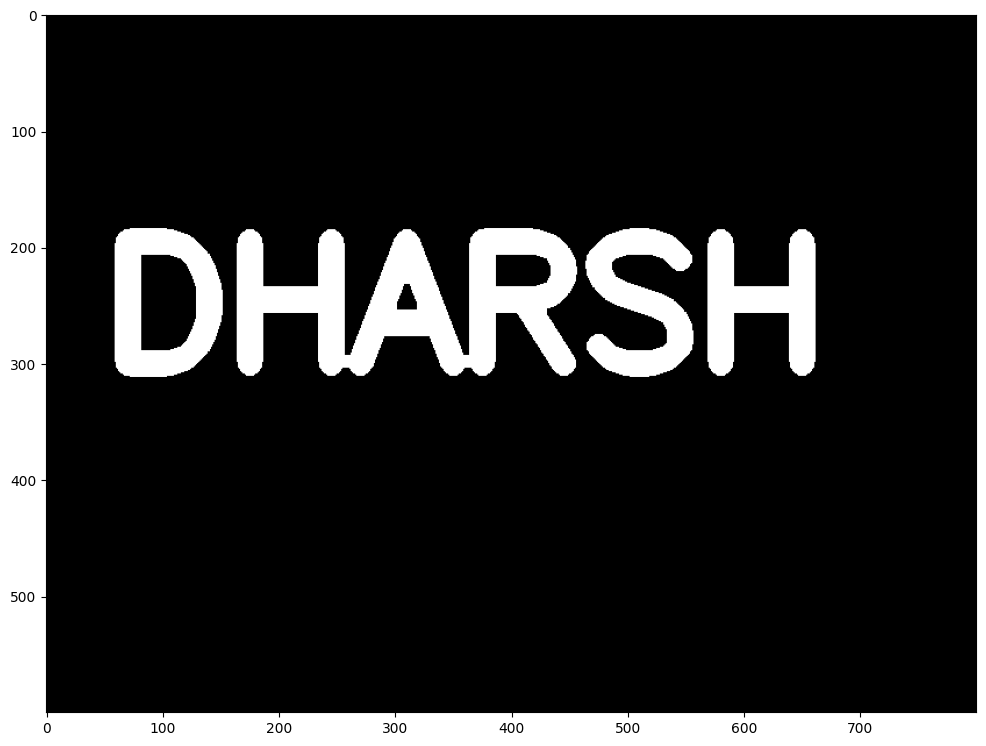

In [38]:
erosion1=cv2.erode(img,kernel,iterations=1)
display_img(erosion1)

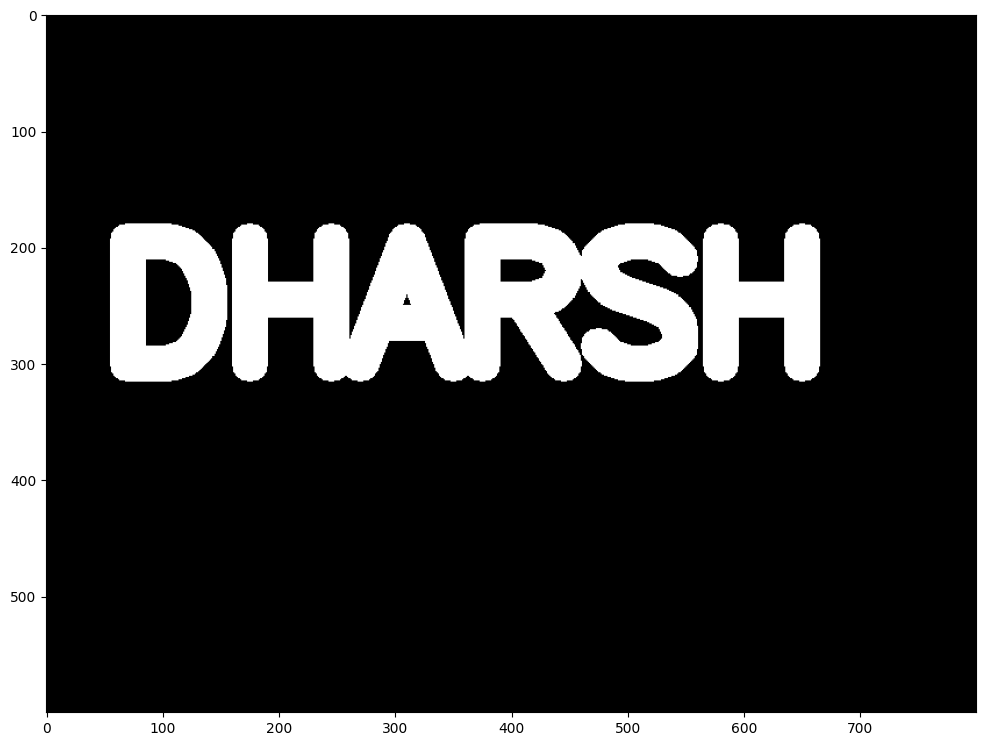

In [39]:
dilu=cv2.dilate(img,kernel,iterations=1)
display_img(dilu)

# OPENING 

In [40]:
img = load_img()

In [41]:
white_noise = np.random.randint(low = 0, high = 2, size = (600,800))

In [42]:
white_noise

array([[0, 0, 0, ..., 0, 1, 0],
       [0, 0, 1, ..., 1, 1, 0],
       [1, 0, 1, ..., 1, 1, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 1, 0, 1],
       [0, 1, 1, ..., 0, 0, 1]], shape=(600, 800), dtype=int32)

In [43]:
img.max()

np.float64(255.0)

In [45]:
white_noise.max()

np.int32(1)

In [46]:
white_noise = white_noise * 255

In [47]:
white_noise.shape

(600, 800)

In [48]:
white_noise

array([[  0,   0,   0, ...,   0, 255,   0],
       [  0,   0, 255, ..., 255, 255,   0],
       [255,   0, 255, ..., 255, 255,   0],
       ...,
       [255, 255, 255, ...,   0,   0,   0],
       [  0,   0, 255, ..., 255,   0, 255],
       [  0, 255, 255, ...,   0,   0, 255]], shape=(600, 800), dtype=int32)

In [50]:
noise_img = white_noise + img

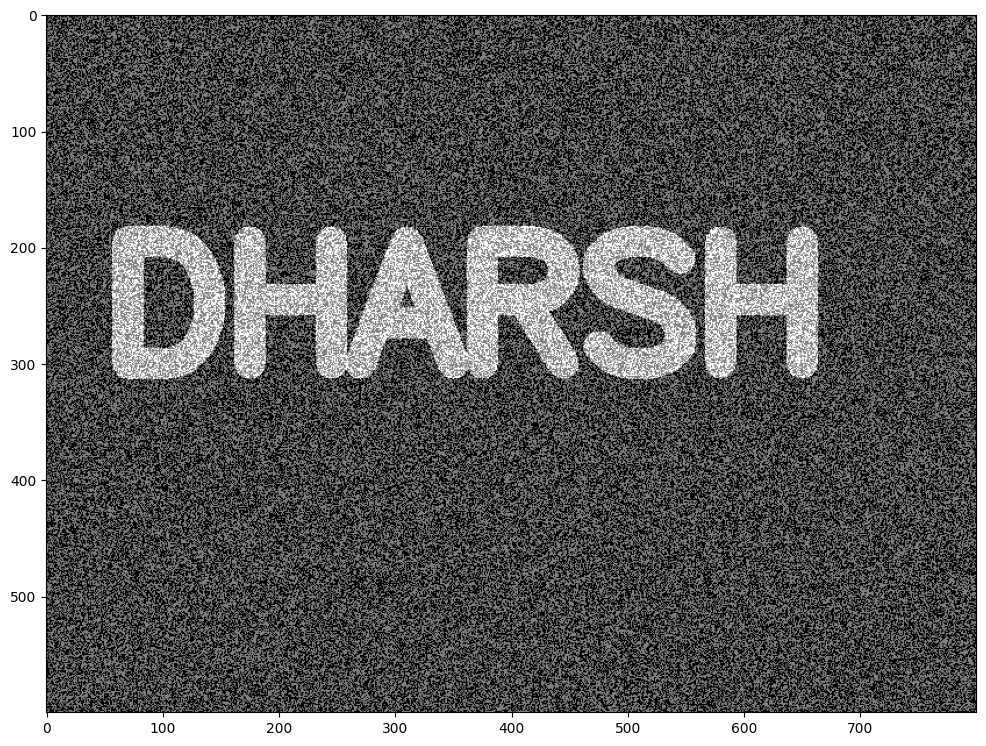

In [51]:
display_img(noise_img)

In [52]:
opening = cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

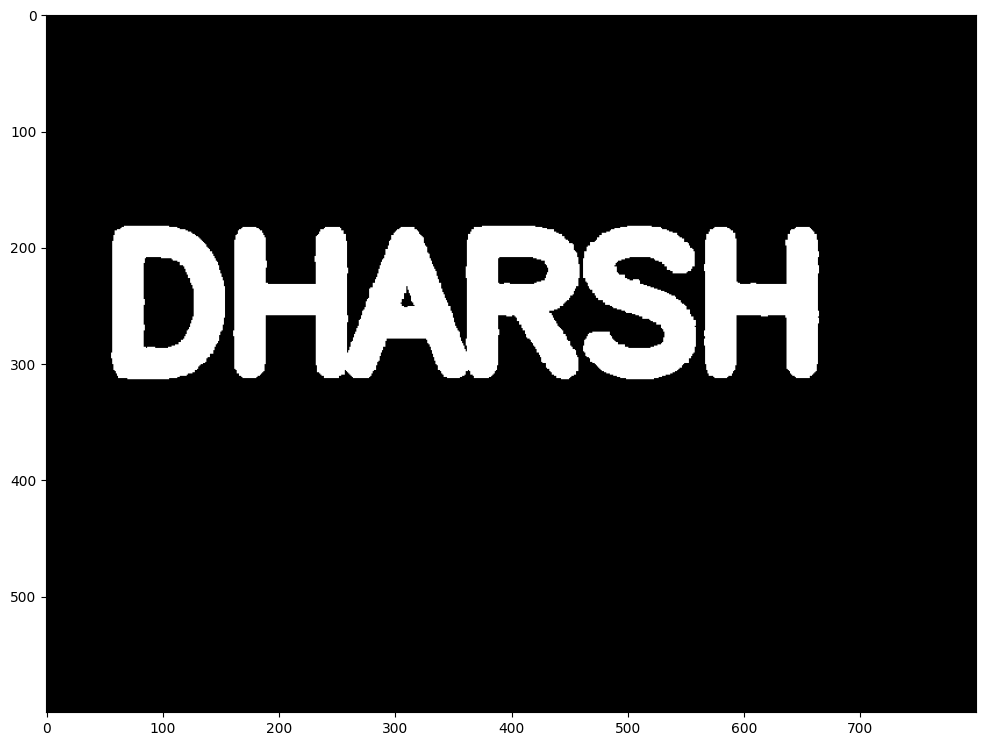

In [53]:
display_img(opening)

# CLOSING

In [54]:
img = load_img()

In [55]:
black_noise = np.random.randint(low = 0, high = 2, size = (600,800))

In [56]:
black_noise

array([[0, 1, 0, ..., 1, 0, 0],
       [1, 0, 1, ..., 0, 1, 0],
       [1, 1, 1, ..., 0, 1, 1],
       ...,
       [1, 1, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 0, 1, 1],
       [0, 1, 0, ..., 1, 1, 0]], shape=(600, 800), dtype=int32)

In [57]:
black_noise = black_noise * -255

In [58]:
black_noise_img = img + black_noise

In [59]:
black_noise_img

array([[   0., -255.,    0., ..., -255.,    0.,    0.],
       [-255.,    0., -255., ...,    0., -255.,    0.],
       [-255., -255., -255., ...,    0., -255., -255.],
       ...,
       [-255., -255.,    0., ..., -255., -255.,    0.],
       [   0.,    0.,    0., ...,    0., -255., -255.],
       [   0., -255.,    0., ..., -255., -255.,    0.]], shape=(600, 800))

In [60]:
black_noise_img[black_noise_img == -255] = 0

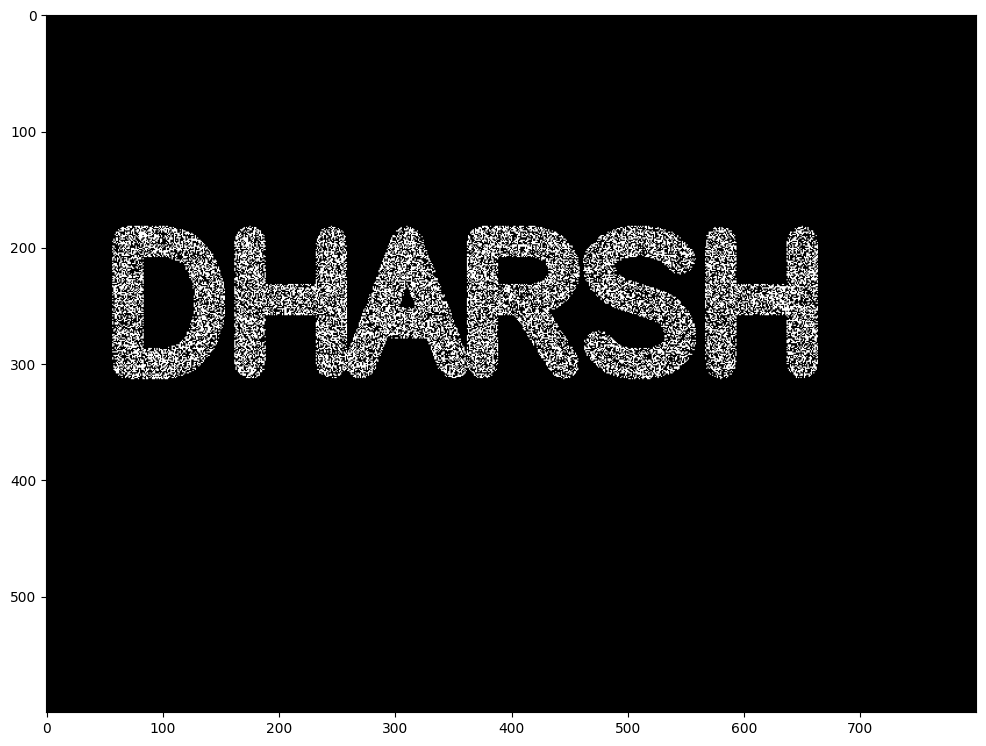

In [61]:
display_img(black_noise_img)